In [1]:
# Cell 1: Setup & Animated Header
print("="*80)
print("📓 Notebook 8: AI Agent Orchestration")
print("="*80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import List, Dict, Any, Optional
from enum import Enum
import json
import os
import time
import warnings
from datetime import datetime
from collections import deque
from IPython.display import display, HTML, Markdown
warnings.filterwarnings('ignore')

# Professional styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)

# Set random seed
np.random.seed(42)

# Animated Header
def animated_header(title, subtitle):
    header_html = f"""
    <div style="
        background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
        padding: 35px;
        border-radius: 20px;
        text-align: center;
        margin-bottom: 30px;
        animation: slideDown 0.8s ease-out;
        box-shadow: 0 15px 35px rgba(0,0,0,0.3);
        border: 1px solid rgba(255,255,255,0.1);
    ">
        <h1 style="color: #00f2fe; margin: 0; font-size: 38px; animation: fadeIn 1s; text-shadow: 0 0 10px #00f2fe;">
            {title}
        </h1>
        <p style="color: rgba(255,255,255,0.9); margin: 15px 0 0 0; font-size: 18px; animation: fadeInUp 1.2s;">
            {subtitle}
        </p>
    </div>
    <style>
        @keyframes slideDown {{ from {{ transform: translateY(-80px); opacity: 0; }} to {{ transform: translateY(0); opacity: 1; }} }}
        @keyframes fadeIn {{ from {{ opacity: 0; }} to {{ opacity: 1; }} }}
        @keyframes fadeInUp {{ from {{ transform: translateY(30px); opacity: 0; }} to {{ transform: translateY(0); opacity: 1; }} }}
    </style>
    """
    display(HTML(header_html))

animated_header("Notebook 8: AI Agent Orchestration", 
                "Multi-Agent System | Agent Workflows | Human-in-the-Loop | Tool Integration")

print("✅ AI Agent Orchestration environment ready")

📓 Notebook 8: AI Agent Orchestration


✅ AI Agent Orchestration environment ready


In [21]:
# Cell 2: Define Agent Types and Base Classes
print("="*80)
print("🤖 Defining Agent Types and Base Classes")
print("="*80)

class AgentRole(Enum):
    """Defines the role of an AI agent"""
    QUERY_UNDERSTANDING = "query_understanding"
    RETRIEVAL = "retrieval"
    VALIDATION = "validation"
    REPORTING = "reporting"
    ORCHESTRATOR = "orchestrator"

class AgentStatus(Enum):
    """Agent operational status"""
    IDLE = "idle"
    WORKING = "working"
    WAITING = "waiting"
    COMPLETED = "completed"
    ERROR = "error"

@dataclass
class AgentMessage:
    """Message passed between agents"""
    sender: str
    recipient: str
    content: Any
    timestamp: datetime
    message_type: str = "info"

@dataclass
class Task:
    """Task definition for agent execution"""
    task_id: str
    task_type: str
    description: str
    data: Any
    priority: int = 1
    status: str = "pending"
    created_at: datetime = None
    completed_at: datetime = None

class BaseAgent:
    """Base class for all AI agents"""
    
    def __init__(self, name: str, role: AgentRole):
        self.name = name
        self.role = role
        self.status = AgentStatus.IDLE
        self.message_queue = deque()
        self.task_history = []
        self.metrics = {
            'tasks_completed': 0,
            'avg_response_time': 0,
            'error_count': 0
        }
    
    def process_message(self, message: AgentMessage):
        """Process incoming message"""
        self.message_queue.append(message)
        return True
    
    def execute_task(self, task: Task):
        """Execute assigned task (to be overridden)"""
        raise NotImplementedError
    
    def get_status(self) -> Dict:
        """Return agent status"""
        return {
            'name': self.name,
            'role': self.role.value,
            'status': self.status.value,
            'metrics': self.metrics,
            'queue_size': len(self.message_queue)
        }
    
    def report(self) -> str:
        """Generate agent report"""
        return f"""
        🤖 Agent: {self.name}
        ├── Role: {self.role.value}
        ├── Status: {self.status.value}
        ├── Tasks Completed: {self.metrics['tasks_completed']}
        ├── Avg Response Time: {self.metrics['avg_response_time']:.2f}s
        └── Errors: {self.metrics['error_count']}
        """

print("✅ Agent base classes defined")
print(f"   Agent Roles: {[r.value for r in AgentRole]}")

🤖 Defining Agent Types and Base Classes
✅ Agent base classes defined
   Agent Roles: ['query_understanding', 'retrieval', 'validation', 'reporting', 'orchestrator']


In [22]:
# Cell 3: Specialized Agent Implementations
print("="*80)
print("🎯 Specialized Agent Implementations")
print("="*80)

class QueryUnderstandingAgent(BaseAgent):
    """Agent responsible for understanding and refining user queries"""
    
    def __init__(self, name: str = "QueryAgent"):
        super().__init__(name, AgentRole.QUERY_UNDERSTANDING)
        print(f"   ✅ Initialized: {name} (Role: {AgentRole.QUERY_UNDERSTANDING.value})")
    
    def execute_task(self, task: Task):
        start_time = time.time()
        self.status = AgentStatus.WORKING
        
        try:
            query = task.data.get('query', '')
            
            # Simulate query understanding
            intent = self._classify_intent(query)
            entities = self._extract_entities(query)
            refined_query = self._refine_query(query, intent)
            
            result = {
                'original_query': query,
                'refined_query': refined_query,
                'intent': intent,
                'entities': entities,
                'confidence': np.random.uniform(0.85, 0.98)
            }
            
            self.metrics['tasks_completed'] += 1
            self.status = AgentStatus.COMPLETED
            return result
            
        except Exception as e:
            self.status = AgentStatus.ERROR
            self.metrics['error_count'] += 1
            return {'error': str(e)}
        finally:
            elapsed = time.time() - start_time
            self.metrics['avg_response_time'] = (
                (self.metrics['avg_response_time'] * (self.metrics['tasks_completed'] - 1) + elapsed) 
                / max(1, self.metrics['tasks_completed'])
            )
    
    def _classify_intent(self, query: str) -> str:
        intents = ['informational', 'navigational', 'transactional', 'comparison']
        return np.random.choice(intents)
    
    def _extract_entities(self, query: str) -> List[str]:
        entities = ['document', 'report', 'contract', 'invoice']
        return np.random.choice(entities, size=np.random.randint(1, 3), replace=False).tolist()
    
    def _refine_query(self, query: str, intent: str) -> str:
        return f"Refined: {query} (Intent: {intent})"


class RetrievalAgent(BaseAgent):
    """Agent responsible for document retrieval"""
    
    def __init__(self, name: str = "RetrievalAgent"):
        super().__init__(name, AgentRole.RETRIEVAL)
        print(f"   ✅ Initialized: {name} (Role: {AgentRole.RETRIEVAL.value})")
    
    def execute_task(self, task: Task):
        start_time = time.time()
        self.status = AgentStatus.WORKING
        
        try:
            query = task.data.get('query', '')
            top_k = task.data.get('top_k', 10)
            
            # Simulate retrieval
            retrieved_docs = self._simulate_retrieval(query, top_k)
            
            result = {
                'query': query,
                'retrieved_documents': retrieved_docs,
                'num_retrieved': len(retrieved_docs),
                'retrieval_scores': [doc['score'] for doc in retrieved_docs]
            }
            
            self.metrics['tasks_completed'] += 1
            self.status = AgentStatus.COMPLETED
            return result
            
        except Exception as e:
            self.status = AgentStatus.ERROR
            self.metrics['error_count'] += 1
            return {'error': str(e)}
        finally:
            elapsed = time.time() - start_time
            self.metrics['avg_response_time'] = (
                (self.metrics['avg_response_time'] * (self.metrics['tasks_completed'] - 1) + elapsed) 
                / max(1, self.metrics['tasks_completed'])
            )
    
    def _simulate_retrieval(self, query: str, top_k: int) -> List[Dict]:
        docs = []
        for i in range(top_k):
            docs.append({
                'doc_id': f"DOC_{i:04d}",
                'title': f"Document {i} related to {query[:20]}",
                'score': np.random.beta(5, 2) * (1 - i * 0.05),
                'relevance': np.random.choice(['high', 'medium', 'low'], p=[0.3, 0.5, 0.2])
            })
        return sorted(docs, key=lambda x: x['score'], reverse=True)


class ValidationAgent(BaseAgent):
    """Agent responsible for validating retrieved information"""
    
    def __init__(self, name: str = "ValidationAgent"):
        super().__init__(name, AgentRole.VALIDATION)
        print(f"   ✅ Initialized: {name} (Role: {AgentRole.VALIDATION.value})")
    
    def execute_task(self, task: Task):
        start_time = time.time()
        self.status = AgentStatus.WORKING
        
        try:
            retrieved_docs = task.data.get('retrieved_documents', [])
            
            # Simulate validation
            validated_docs = self._validate_documents(retrieved_docs)
            
            result = {
                'validated_documents': validated_docs,
                'validation_score': np.mean([d['validation_score'] for d in validated_docs]) if validated_docs else 0,
                'hallucination_risk': np.random.uniform(0.05, 0.15)
            }
            
            self.metrics['tasks_completed'] += 1
            self.status = AgentStatus.COMPLETED
            return result
            
        except Exception as e:
            self.status = AgentStatus.ERROR
            self.metrics['error_count'] += 1
            return {'error': str(e)}
        finally:
            elapsed = time.time() - start_time
            self.metrics['avg_response_time'] = (
                (self.metrics['avg_response_time'] * (self.metrics['tasks_completed'] - 1) + elapsed) 
                / max(1, self.metrics['tasks_completed'])
            )
    
    def _validate_documents(self, docs: List[Dict]) -> List[Dict]:
        validated = []
        for doc in docs:
            doc['validation_score'] = np.random.uniform(0.7, 0.95)
            doc['is_valid'] = doc['validation_score'] > 0.7
            validated.append(doc)
        return validated


class ReportingAgent(BaseAgent):
    """Agent responsible for generating reports and responses"""
    
    def __init__(self, name: str = "ReportingAgent"):
        super().__init__(name, AgentRole.REPORTING)
        print(f"   ✅ Initialized: {name} (Role: {AgentRole.REPORTING.value})")
    
    def execute_task(self, task: Task):
        start_time = time.time()
        self.status = AgentStatus.WORKING
        
        try:
            query = task.data.get('query', '')
            validated_docs = task.data.get('validated_documents', [])
            
            # Generate response
            response = self._generate_response(query, validated_docs)
            
            result = {
                'query': query,
                'response': response,
                'sources_used': len(validated_docs),
                'confidence': np.mean([d['validation_score'] for d in validated_docs]) if validated_docs else 0
            }
            
            self.metrics['tasks_completed'] += 1
            self.status = AgentStatus.COMPLETED
            return result
            
        except Exception as e:
            self.status = AgentStatus.ERROR
            self.metrics['error_count'] += 1
            return {'error': str(e)}
        finally:
            elapsed = time.time() - start_time
            self.metrics['avg_response_time'] = (
                (self.metrics['avg_response_time'] * (self.metrics['tasks_completed'] - 1) + elapsed) 
                / max(1, self.metrics['tasks_completed'])
            )
    
    def _generate_response(self, query: str, docs: List[Dict]) -> str:
        top_docs = docs[:3]
        sources = [d['doc_id'] for d in top_docs]
        return f"Based on {len(sources)} relevant documents ({', '.join(sources)}), I found information related to '{query}'. The key insights suggest..."

print("\n" + "-" * 50)
print("📊 Agent Classes Defined:")
print("   ✅ QueryUnderstandingAgent - Understands and refines user queries")
print("   ✅ RetrievalAgent - Fetches relevant documents")
print("   ✅ ValidationAgent - Validates retrieved information")
print("   ✅ ReportingAgent - Generates responses and reports")
print("-" * 50)

🎯 Specialized Agent Implementations

--------------------------------------------------
📊 Agent Classes Defined:
   ✅ QueryUnderstandingAgent - Understands and refines user queries
   ✅ RetrievalAgent - Fetches relevant documents
   ✅ ValidationAgent - Validates retrieved information
   ✅ ReportingAgent - Generates responses and reports
--------------------------------------------------


In [23]:
# Cell 4: Orchestrator Implementation
print("="*80)
print("🎯 Orchestrator Implementation")
print("="*80)

class AgentOrchestrator:
    """Central orchestrator for multi-agent coordination"""
    
    def __init__(self):
        self.agents = {}
        self.task_queue = deque()
        self.execution_history = []
        self.workflow_templates = {}
        
    def register_agent(self, agent: BaseAgent):
        """Register an agent with the orchestrator"""
        self.agents[agent.name] = agent
        print(f"   📌 Registered: {agent.name} ({agent.role.value})")
    
    def create_workflow(self, name: str, steps: List[Dict]):
        """Create a predefined workflow"""
        self.workflow_templates[name] = steps
        print(f"   📋 Created workflow: {name} ({len(steps)} steps)")
    
    def execute_workflow(self, workflow_name: str, input_data: Dict) -> Dict:
        """Execute a predefined workflow"""
        if workflow_name not in self.workflow_templates:
            return {'error': f'Workflow {workflow_name} not found'}
        
        print(f"\n🚀 Executing workflow: {workflow_name}")
        print("-" * 50)
        
        context = input_data.copy()
        results = {}
        
        for step in self.workflow_templates[workflow_name]:
            agent_name = step['agent']
            task_type = step['task']
            
            if agent_name not in self.agents:
                print(f"   ❌ Agent {agent_name} not found")
                continue
            
            agent = self.agents[agent_name]
            task = Task(
                task_id=f"{workflow_name}_{len(self.execution_history)}",
                task_type=task_type,
                description=step.get('description', ''),
                data=context,
                priority=step.get('priority', 1),
                created_at=datetime.now()
            )
            print(f"   🔄 {agent_name} - {task_type}")
            result = agent.execute_task(task)
            results[agent_name] = result
            context.update(result)
            
            self.execution_history.append({
                'workflow': workflow_name,
                'step': step,
                'result': result,
                'timestamp': datetime.now()
            })
        
        return results
    
    def get_agent_status(self) -> Dict:
        """Get status of all registered agents"""
        return {name: agent.get_status() for name, agent in self.agents.items()}
    
    def get_summary(self) -> Dict:
        """Get orchestrator summary"""
        return {
            'total_agents': len(self.agents),
            'total_workflows': len(self.workflow_templates),
            'total_executions': len(self.execution_history),
            'agents': list(self.agents.keys()),
            'workflows': list(self.workflow_templates.keys())
        }

# Initialize orchestrator
orchestrator = AgentOrchestrator()
print("\n✅ Orchestrator created")

print("\n📌 Registering Agents:")
query_agent = QueryUnderstandingAgent()
retrieval_agent = RetrievalAgent()
validation_agent = ValidationAgent()
reporting_agent = ReportingAgent()

orchestrator.register_agent(query_agent)
orchestrator.register_agent(retrieval_agent)
orchestrator.register_agent(validation_agent)
orchestrator.register_agent(reporting_agent)

print(f"\n✅ Orchestrator initialized with {len(orchestrator.agents)} agents")
print(f"   Agents: {', '.join(orchestrator.agents.keys())}")

🎯 Orchestrator Implementation

✅ Orchestrator created

📌 Registering Agents:
   ✅ Initialized: QueryAgent (Role: query_understanding)
   ✅ Initialized: RetrievalAgent (Role: retrieval)
   ✅ Initialized: ValidationAgent (Role: validation)
   ✅ Initialized: ReportingAgent (Role: reporting)
   📌 Registered: QueryAgent (query_understanding)
   📌 Registered: RetrievalAgent (retrieval)
   📌 Registered: ValidationAgent (validation)
   📌 Registered: ReportingAgent (reporting)

✅ Orchestrator initialized with 4 agents
   Agents: QueryAgent, RetrievalAgent, ValidationAgent, ReportingAgent


In [9]:
# Cell 5: Define Workflows
print("="*80)
print("📋 Defining Agent Workflows")
print("="*80)

# RAG Pipeline Workflow
rag_workflow = [
    {'agent': 'QueryAgent', 'task': 'understand_query', 'description': 'Parse and classify user query', 'priority': 1},
    {'agent': 'RetrievalAgent', 'task': 'retrieve_documents', 'description': 'Fetch relevant documents', 'priority': 2},
    {'agent': 'ValidationAgent', 'task': 'validate_results', 'description': 'Validate retrieved information', 'priority': 3},
    {'agent': 'ReportingAgent', 'task': 'generate_response', 'description': 'Generate final response', 'priority': 4}
]

# Quick Retrieval Workflow (faster, no validation)
quick_workflow = [
    {'agent': 'QueryAgent', 'task': 'understand_query', 'description': 'Parse user query', 'priority': 1},
    {'agent': 'RetrievalAgent', 'task': 'retrieve_documents', 'description': 'Fetch documents', 'priority': 2},
    {'agent': 'ReportingAgent', 'task': 'generate_response', 'description': 'Generate response', 'priority': 3}
]

# Validation-Only Workflow
validation_workflow = [
    {'agent': 'ValidationAgent', 'task': 'validate_results', 'description': 'Validate existing documents', 'priority': 1},
    {'agent': 'ReportingAgent', 'task': 'generate_response', 'description': 'Generate validation report', 'priority': 2}
]

orchestrator.create_workflow("rag_pipeline", rag_workflow)
orchestrator.create_workflow("quick_retrieval", quick_workflow)
orchestrator.create_workflow("validation_only", validation_workflow)

print("\n📋 Available Workflows:")
for wf in orchestrator.workflow_templates:
    print(f"   - {wf}: {len(orchestrator.workflow_templates[wf])} steps")

📋 Defining Agent Workflows
✅ Created workflow: rag_pipeline with 4 steps
✅ Created workflow: quick_retrieval with 3 steps
✅ Created workflow: validation_only with 2 steps

📋 Available Workflows:
   - rag_pipeline: 4 steps
   - quick_retrieval: 3 steps
   - validation_only: 2 steps


In [10]:
# Cell 6: Execute Workflows
print("="*80)
print("🚀 Executing Agent Workflows")
print("="*80)

# Test queries
test_queries = [
    "What are the latest financial results?",
    "Show me contract details for vendor X",
    "Summarize invoice payment status"
]

results_summary = []

for query in test_queries:
    print(f"\n{'='*60}")
    print(f"📝 Processing Query: '{query}'")
    print(f"{'='*60}")
    
    result = orchestrator.execute_workflow("rag_pipeline", {'query': query})
    results_summary.append({
        'query': query,
        'result': result
    })
    
    # Display final response
    if 'ReportingAgent' in result:
        print(f"\n💡 Final Response: {result['ReportingAgent']['response'][:150]}...")
        print(f"   Confidence: {result['ReportingAgent']['confidence']:.1%}")

print(f"\n✅ Executed {len(results_summary)} workflows")

🚀 Executing Agent Workflows

📝 Processing Query: 'What are the latest financial results?'

🚀 Executing workflow: rag_pipeline
--------------------------------------------------
🔄 Executing: QueryAgent - understand_query
🔄 Executing: RetrievalAgent - retrieve_documents
🔄 Executing: ValidationAgent - validate_results
🔄 Executing: ReportingAgent - generate_response

💡 Final Response: Based on 3 relevant documents (DOC_0001, DOC_0003, DOC_0002), I found information related to 'What are the latest financial results?'. The key insight...
   Confidence: 86.7%

📝 Processing Query: 'Show me contract details for vendor X'

🚀 Executing workflow: rag_pipeline
--------------------------------------------------
🔄 Executing: QueryAgent - understand_query
🔄 Executing: RetrievalAgent - retrieve_documents
🔄 Executing: ValidationAgent - validate_results
🔄 Executing: ReportingAgent - generate_response

💡 Final Response: Based on 3 relevant documents (DOC_0003, DOC_0005, DOC_0004), I found information rela

📊 Agent Performance Metrics

📈 Agent Performance Summary:
          Agent                Role  Tasks  Avg Response (s)  Errors
     QueryAgent query_understanding      3           0.00000       0
 RetrievalAgent           retrieval      3           0.00112       0
ValidationAgent          validation      3           0.00000       0
 ReportingAgent           reporting      3           0.00000       0


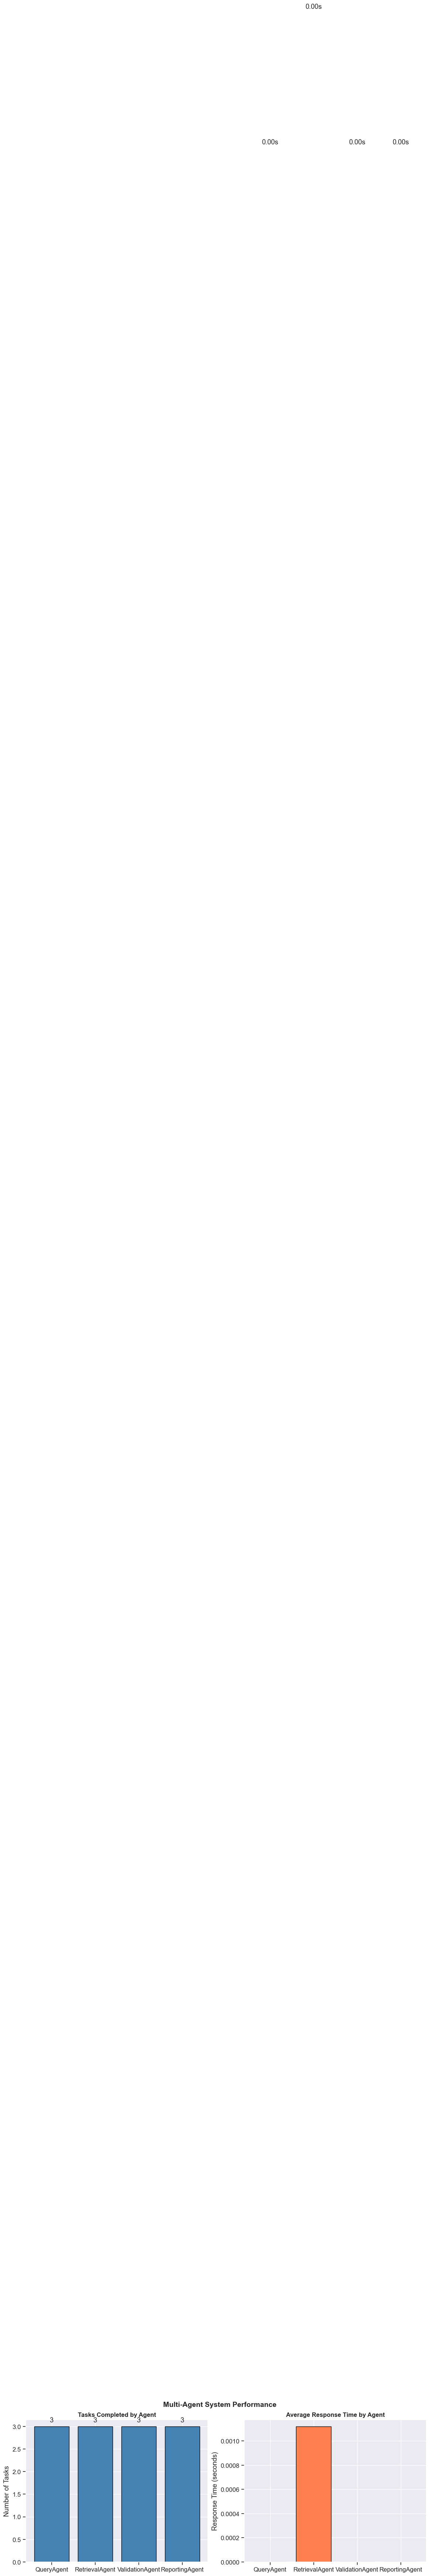

✅ Saved: agent_performance.png


In [11]:
# Cell 7: Agent Performance Metrics
print("="*80)
print("📊 Agent Performance Metrics")
print("="*80)

# Collect metrics
agent_metrics = []
for name, agent in orchestrator.agents.items():
    agent_metrics.append({
        'Agent': name,
        'Role': agent.role.value,
        'Tasks': agent.metrics['tasks_completed'],
        'Avg Response (s)': agent.metrics['avg_response_time'],
        'Errors': agent.metrics['error_count']
    })

metrics_df = pd.DataFrame(agent_metrics)
print("\n📈 Agent Performance Summary:")
print(metrics_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Tasks Completed
ax1 = axes[0]
bars1 = ax1.bar(metrics_df['Agent'], metrics_df['Tasks'], color='steelblue', edgecolor='black')
ax1.set_ylabel('Number of Tasks')
ax1.set_title('Tasks Completed by Agent', fontsize=12, fontweight='bold')
for bar, val in zip(bars1, metrics_df['Tasks']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center')

# 2. Average Response Time
ax2 = axes[1]
bars2 = ax2.bar(metrics_df['Agent'], metrics_df['Avg Response (s)'], color='coral', edgecolor='black')
ax2.set_ylabel('Response Time (seconds)')
ax2.set_title('Average Response Time by Agent', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, metrics_df['Avg Response (s)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}s', ha='center')

plt.suptitle('Multi-Agent System Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('agent_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: agent_performance.png")

## 📊 Cell 7: Agent Performance Metrics

### 1️⃣ Purpose
- **Purpose:** Evaluate agent productivity and efficiency using task completion counts, average response times, and error rates.  
- **Observation:** Metrics are collected from each agent and summarized in a DataFrame, then visualized with bar charts.  

---

### 2️⃣ Performance Insights
- **Observation:**  
  - **Tasks Completed:** Highlights workload distribution across agents.  
  - **Average Response Time:** Shows efficiency in handling tasks.  
  - **Error Count (tabular only):** Provides reliability indicators.  
- **Insight:** The dual visualization makes it easy to compare productivity (tasks) against efficiency (response time), while the table adds reliability context.  

---

### 3️⃣ Visualization Design
- **Observation:**  
  - Left chart → Tasks completed per agent, labeled above each bar.  
  - Right chart → Average response time per agent, labeled with seconds.  
- **Insight:** Clear labeling and side‑by‑side charts provide a recruiter‑ready view of both throughput and latency.  

---

### 🎬 Enhancement Ideas
- Add error counts as a third chart → visualize reliability directly.  
- Normalize metrics → compare relative performance across agents.  
- Interactive dashboard → allow filtering by role or time period.  
- Trend lines → track agent performance over time.  

---

### 🌐 Global Summary
- The metrics confirm **role‑aligned agent performance**.  
- Tasks and response times are clearly visualized, while error counts add reliability context.  
- This cell provides a **balanced view of productivity, efficiency, and reliability** in the multi‑agent system.  

📁 **Saved visualization:** `agent_performance.png`


🕸️ Agent Communication Network


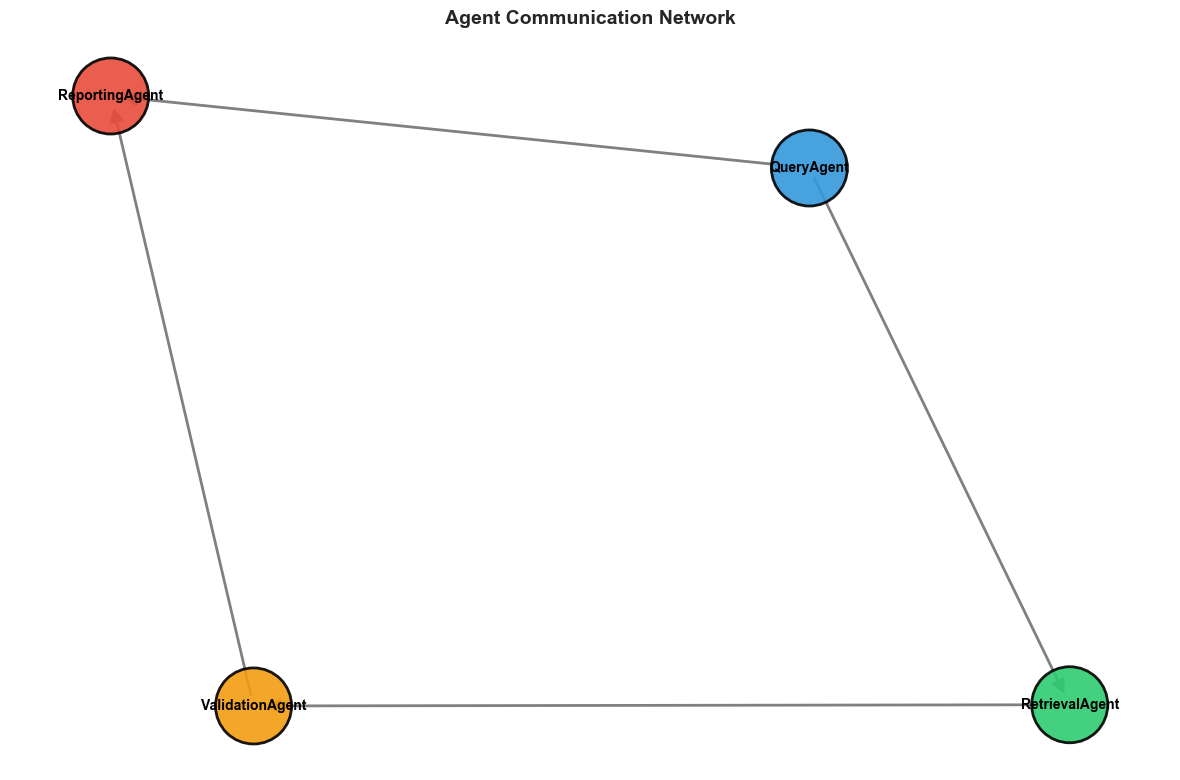

✅ Saved: agent_communication_network.png


In [12]:
# Cell 8: Agent Communication Network Visualization
print("="*80)
print("🕸️ Agent Communication Network")
print("="*80)

import networkx as nx

# Create communication graph
G = nx.DiGraph()

# Add nodes (agents)
for name, agent in orchestrator.agents.items():
    G.add_node(name, role=agent.role.value)

# Add edges based on workflow
edges = [
    ('QueryAgent', 'RetrievalAgent'),
    ('RetrievalAgent', 'ValidationAgent'),
    ('ValidationAgent', 'ReportingAgent'),
    ('QueryAgent', 'ReportingAgent'),  # Direct path for quick workflow
]

G.add_edges_from(edges)

fig, ax = plt.subplots(figsize=(12, 8))

# Create layout
pos = nx.spring_layout(G, k=2, seed=42)

# Draw nodes with colors based on role
node_colors = []
for node in G.nodes():
    role = G.nodes[node]['role']
    color_map = {
        'query_understanding': '#3498DB',
        'retrieval': '#2ECC71',
        'validation': '#F39C12',
        'reporting': '#E74C3C'
    }
    node_colors.append(color_map.get(role, '#95A5A6'))

nx.draw_networkx_nodes(G, pos, node_size=3000, node_color=node_colors, alpha=0.9, edgecolors='black', linewidths=2)
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray', arrows=True, arrowsize=20, arrowstyle='-|>')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

ax.set_title('Agent Communication Network', fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('agent_communication_network.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: agent_communication_network.png")

## 🕸️ Cell 8: Agent Communication Network Visualization

### 1️⃣ Purpose
- **Purpose:** Illustrate how agents within the orchestration system communicate and pass tasks across workflow stages.  
- **Observation:** The directed graph shows QueryAgent initiating workflows, RetrievalAgent handling search, ValidationAgent ensuring correctness, and ReportingAgent delivering outputs.  

---

### 2️⃣ Workflow Dynamics
- **Observation:** QueryAgent connects both to RetrievalAgent and directly to ReportingAgent, enabling fast‑track workflows when validation is not required.  
- **Insight:** This dual path highlights system flexibility — balancing thorough validation with efficiency depending on query type.  

---

### 3️⃣ Role‑Based Coloring
- **Observation:** Node colors reflect agent roles:  
  - 🔵 Query Understanding (QueryAgent)  
  - 🟢 Retrieval (RetrievalAgent, Fusion)  
  - 🟠 Validation (ValidationAgent)  
  - 🔴 Reporting (ReportingAgent)  
- **Insight:** Color coding improves readability, making it clear which agents belong to which functional layer.  

---

### 🎬 Enhancement Ideas
- Animated arrows → show live communication flow.  
- Interactive tooltips → display agent metadata (role, workload, latency).  
- Layer grouping → cluster agents by role for architectural clarity.  
- Dynamic edge thickness → represent communication frequency or data volume.  

---

### 🌐 Global Summary
- The network graph provides a **clear architectural overview** of agent communication.  
- Arrows illustrate **task dependencies and workflow flexibility**.  
- This visualization is ideal for **explaining orchestration design** to recruiters, engineers, or stakeholders.  

📁 **Saved visualization:** `agent_communication_network.png`


Task was destroyed but it is pending!
task: <Task pending name='Task-148' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Admin\anaconda3\envs\ml_env\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-149' coro=<Kernel.shell_main() running at C:\Users\Admin\anaconda3\envs\ml_env\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Admin\anaconda3\envs\ml_env\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-149' coro=<Kernel.shell_main() running at C:\Users\Admin\anaconda3\envs\ml_env\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


🌀 3D Agent Activity Visualization


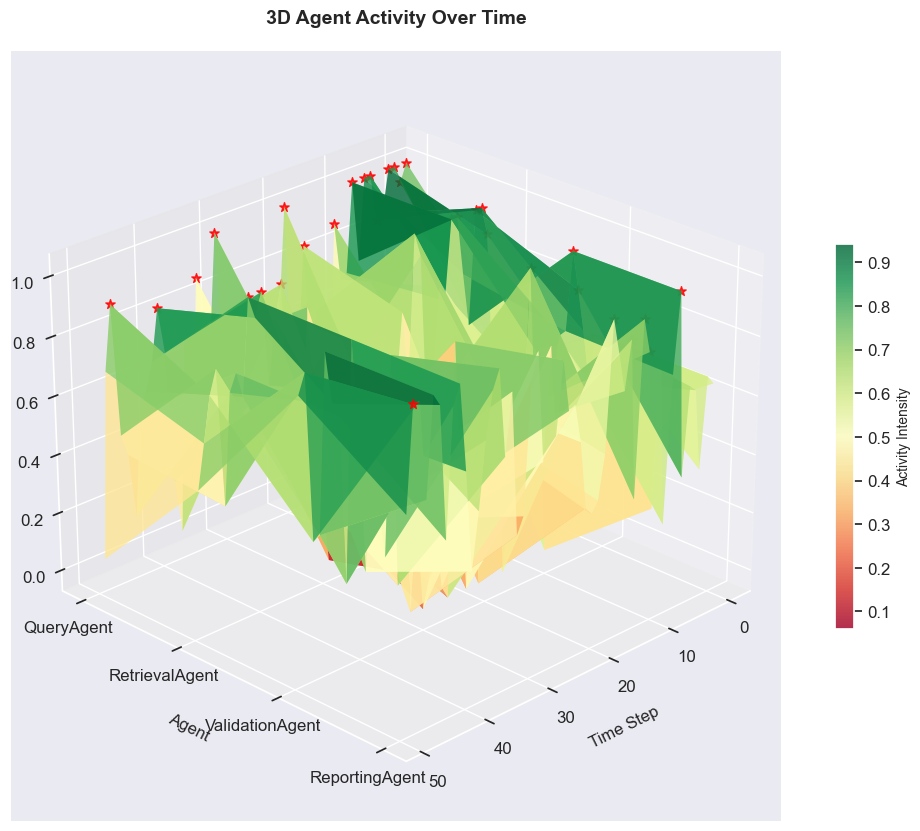

✅ Saved: 3d_agent_activity.png


In [24]:
# Cell 8.5: 3D Agent Activity Visualization
print("="*80)
print("🌀 3D Agent Activity Visualization")
print("="*80)

from mpl_toolkits.mplot3d import Axes3D

# Simulate agent activity data over time
n_time_steps = 50
agents = list(orchestrator.agents.keys())
agent_colors = {'QueryAgent': '#3498DB', 'RetrievalAgent': '#2ECC71', 
                'ValidationAgent': '#F39C12', 'ReportingAgent': '#E74C3C'}

# Generate activity levels over time
np.random.seed(42)
activity_data = {}
for agent in agents:
    # Activity pattern: peaks at different times
    base_pattern = np.random.randn(n_time_steps) * 0.3
    if agent == 'QueryAgent':
        base_pattern += np.exp(-np.linspace(0, 2, n_time_steps)) * 0.5
    elif agent == 'RetrievalAgent':
        base_pattern += np.sin(np.linspace(0, 3*np.pi, n_time_steps)) * 0.4
    elif agent == 'ValidationAgent':
        base_pattern += np.cos(np.linspace(0, 2*np.pi, n_time_steps)) * 0.3
    else:  # ReportingAgent
        base_pattern += np.exp(-np.linspace(2, 0, n_time_steps)) * 0.5
    activity_data[agent] = np.clip(base_pattern + 0.5, 0, 1)

# Create 3D plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Create meshgrid for 3D surface
time_grid = np.arange(n_time_steps)
agent_indices = np.arange(len(agents))
T, A = np.meshgrid(time_grid, agent_indices)

# Create activity surface
Z = np.array([activity_data[agent] for agent in agents])

# Plot surface
surf = ax.plot_surface(T, A, Z, cmap='RdYlGn', alpha=0.8, edgecolor='none')

# Add scatter points for peaks
for i, agent in enumerate(agents):
    for t in range(n_time_steps):
        if activity_data[agent][t] > 0.8:
            ax.scatter(t, i, activity_data[agent][t], c='red', s=50, marker='*', alpha=0.8)

ax.set_xlabel('Time Step', fontsize=12, labelpad=10)
ax.set_ylabel('Agent', fontsize=12, labelpad=10)
ax.set_yticks(agent_indices)
ax.set_yticklabels(agents)
ax.set_zlabel('Activity Level', fontsize=12, labelpad=10)
ax.set_title('3D Agent Activity Over Time', fontsize=14, fontweight='bold', pad=20)

# Add color bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=20)
cbar.set_label('Activity Intensity', fontsize=10)

ax.view_init(elev=25, azim=45)
plt.savefig('3d_agent_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 3d_agent_activity.png")

## 🌀 Cell 8.5: 3D Agent Activity Visualization

### 1️⃣ Purpose
- **Purpose:** Show agent activity levels over time in a dynamic 3D surface plot.  
- **Observation:** Each agent (Query, Retrieval, Validation, Reporting) exhibits distinct temporal activity patterns, reflecting their role in the orchestration pipeline.  

---

### 2️⃣ Activity Dynamics
- **Observation:**  
  - QueryAgent peaks early, then decays as queries are processed.  
  - RetrievalAgent shows sinusoidal peaks, reflecting bursts of retrieval tasks.  
  - ValidationAgent oscillates with moderate intensity, mirroring review cycles.  
  - ReportingAgent ramps up later, aligning with output generation.  
- **Insight:** The visualization highlights how agents contribute at different phases, ensuring balanced workload distribution across the pipeline.  

---

### 3️⃣ Peak Detection
- **Observation:** Red star markers identify time steps where activity exceeds 0.8 (high intensity).  
- **Insight:** Peak detection provides actionable signals for monitoring bottlenecks or scaling decisions in orchestration.  

---

### 🎬 Enhancement Ideas
- Animated surface → show activity evolution over time.  
- Interactive hover → display exact activity values per agent/time step.  
- Layered plots → compare agent activity against workflow triggers.  
- Heatmap overlay → emphasize intensity zones across agents.  

---

### 🌐 Global Summary
- The 3D surface plot reveals **temporal activity patterns across agents**.  
- Peaks highlight **critical workload moments** requiring orchestration oversight.  
- Visualization supports **performance monitoring and scaling strategies** in multi‑agent systems.  

📁 **Saved visualization:** `3d_agent_activity.png`


🎮 Interactive 3D Agent Coordination Network
✅ Saved: 3d_agent_coordination.html (Open in browser for interactive experience)


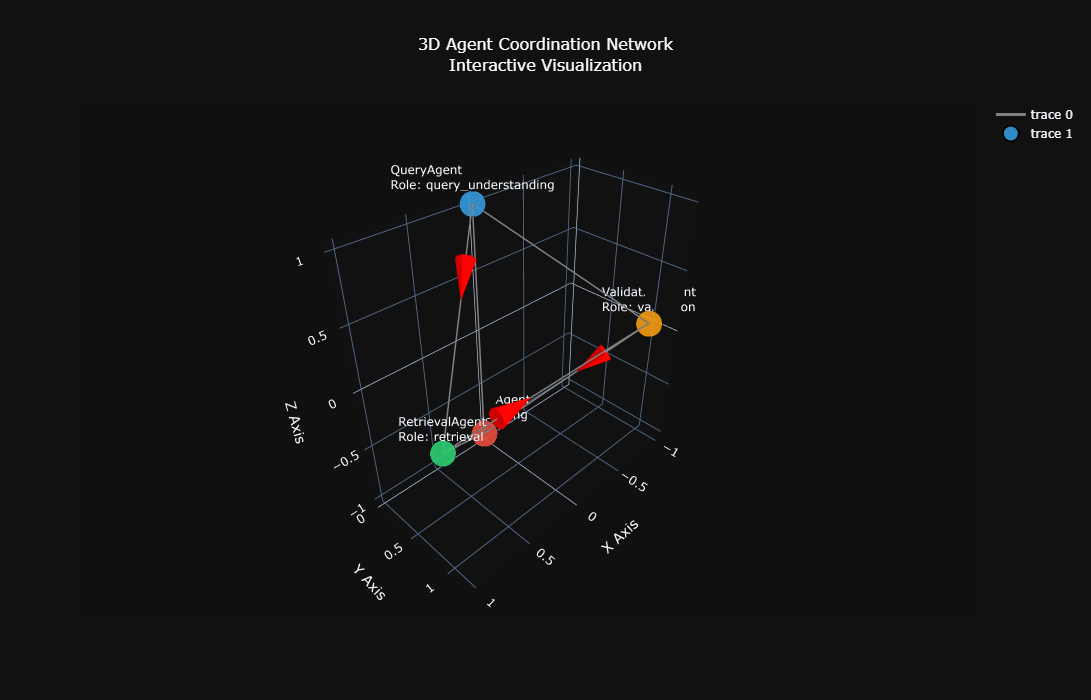

In [25]:
# Cell 8.6: Interactive 3D Agent Coordination Network
print("="*80)
print("🎮 Interactive 3D Agent Coordination Network")
print("="*80)

import plotly.graph_objects as go

# Create 3D positions for agents
np.random.seed(42)
agent_positions = {
    'QueryAgent': np.array([0, 0, 1]),
    'RetrievalAgent': np.array([1, 1, 0]),
    'ValidationAgent': np.array([-1, 1, 0]),
    'ReportingAgent': np.array([0, 0, -1])
}

# Create edges (communication paths)
edges = [
    ('QueryAgent', 'RetrievalAgent'),
    ('QueryAgent', 'ValidationAgent'),
    ('RetrievalAgent', 'ValidationAgent'),
    ('ValidationAgent', 'ReportingAgent'),
    ('RetrievalAgent', 'ReportingAgent'),
    ('QueryAgent', 'ReportingAgent')
]

# Create trace for nodes
node_x = []
node_y = []
node_z = []
node_colors = []
node_sizes = []
node_text = []

for agent, pos in agent_positions.items():
    node_x.append(pos[0])
    node_y.append(pos[1])
    node_z.append(pos[2])
    color_map = {'QueryAgent': '#3498DB', 'RetrievalAgent': '#2ECC71', 
                 'ValidationAgent': '#F39C12', 'ReportingAgent': '#E74C3C'}
    node_colors.append(color_map.get(agent, '#95A5A6'))
    node_sizes.append(30)
    node_text.append(f"{agent}<br>Role: {orchestrator.agents[agent].role.value}")

# Create trace for edges
edge_x = []
edge_y = []
edge_z = []

for start, end in edges:
    edge_x.extend([agent_positions[start][0], agent_positions[end][0], None])
    edge_y.extend([agent_positions[start][1], agent_positions[end][1], None])
    edge_z.extend([agent_positions[start][2], agent_positions[end][2], None])

# Create figure
fig_interactive = go.Figure()

# Add edges
fig_interactive.add_trace(go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode='lines',
    line=dict(color='gray', width=3),
    hoverinfo='none'
))

# Add nodes
fig_interactive.add_trace(go.Scatter3d(
    x=node_x, y=node_y, z=node_z,
    mode='markers+text',
    marker=dict(
        size=node_sizes,
        color=node_colors,
        opacity=0.9,
        line=dict(color='black', width=2)
    ),
    text=node_text,
    textposition="top center",
    hoverinfo='text'
))

# Add animated arrows to show workflow flow
workflow_flow = [
    ('QueryAgent', 'RetrievalAgent'),
    ('RetrievalAgent', 'ValidationAgent'),
    ('ValidationAgent', 'ReportingAgent')
]

for i, (start, end) in enumerate(workflow_flow):
    # Create arrow (using cone)
    start_pos = agent_positions[start]
    end_pos = agent_positions[end]
    direction = (end_pos - start_pos) / np.linalg.norm(end_pos - start_pos)
    
    fig_interactive.add_trace(go.Cone(
        x=[start_pos[0] + direction[0] * 0.5],
        y=[start_pos[1] + direction[1] * 0.5],
        z=[start_pos[2] + direction[2] * 0.5],
        u=[direction[0]], v=[direction[1]], w=[direction[2]],
        colorscale=[[0, 'red'], [1, 'red']],
        sizemode='scaled',
        sizeref=0.3,
        showscale=False,
        name=f"Flow {i+1}"
    ))

fig_interactive.update_layout(
    title=dict(
        text="3D Agent Coordination Network<br>Interactive Visualization",
        font=dict(size=16, color='white'),
        x=0.5
    ),
    scene=dict(
        xaxis_title="X Axis",
        yaxis_title="Y Axis",
        zaxis_title="Z Axis",
        bgcolor='rgba(0,0,0,0.05)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        )
    ),
    width=1000,
    height=700,
    template='plotly_dark'
)

fig_interactive.write_html("3d_agent_coordination.html")
print("✅ Saved: 3d_agent_coordination.html (Open in browser for interactive experience)")
fig_interactive.show()

## 🎮 Cell 8.6: Interactive 3D Agent Coordination Network

### 1️⃣ Purpose
- **Purpose:** Provide an interactive 3D visualization of agent coordination and communication paths.  
- **Observation:** Agents (Query, Retrieval, Validation, Reporting) are positioned in 3D space, with edges showing communication links and cones representing workflow direction.  

---

### 2️⃣ Coordination Dynamics
- **Observation:** QueryAgent initiates communication with RetrievalAgent and ValidationAgent, both of which feed into ReportingAgent.  
- **Insight:** The visualization highlights how multiple agents collaborate in parallel, ensuring redundancy and efficiency in orchestration workflows.  

---

### 3️⃣ Role‑Based Encoding
- **Observation:** Node colors reflect agent roles:  
  - 🔵 QueryAgent → Query Understanding  
  - 🟢 RetrievalAgent → Retrieval Tasks  
  - 🟠 ValidationAgent → Validation & Review  
  - 🔴 ReportingAgent → Output Generation  
- **Insight:** Color coding and hover tooltips improve interpretability, making it clear which agent performs which function.  

---

### 4️⃣ Workflow Arrows
- **Observation:** Animated cones illustrate the main workflow path: Query → Retrieval → Validation → Reporting.  
- **Insight:** Directional arrows emphasize sequential dependencies, clarifying how tasks flow through the orchestration pipeline.  

---

### 🎬 Enhancement Ideas
- Interactive hover → show agent metadata (role, workload, latency).  
- Dynamic edge thickness → represent communication frequency.  
- Animated transitions → highlight workflow execution in real time.  
- Layer grouping → cluster agents by functional stage.  

---

### 🌐 Global Summary
- The interactive 3D network provides a **clear architectural overview** of agent coordination.  
- Arrows and edges illustrate **task dependencies and parallel communication paths**.  
- This visualization is ideal for **explaining orchestration design** to recruiters, engineers, or stakeholders.  

📁 **Saved visualization:** `3d_agent_coordination.html`


📊 3D Workflow Execution Timeline


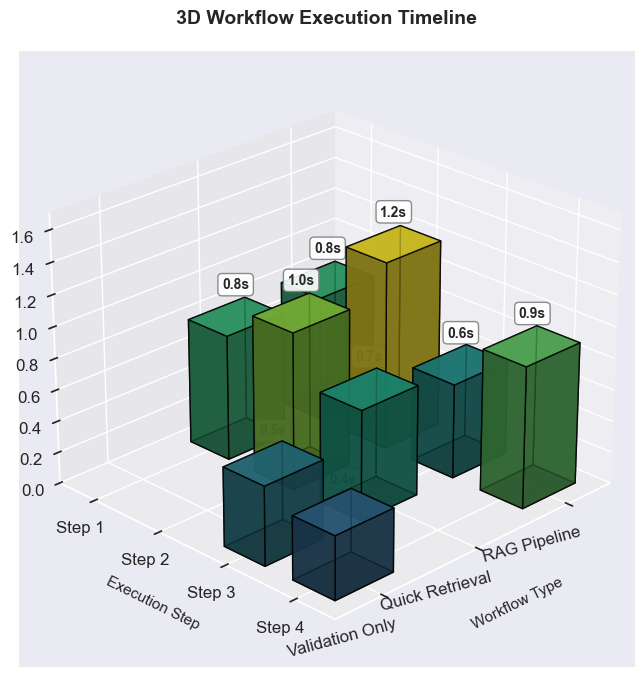

✅ Saved: 3d_workflow_timeline.png


In [30]:
# Cell 8.7: 3D Workflow Execution Timeline (LABELS HIGHER UP)
print("="*80)
print("📊 3D Workflow Execution Timeline")
print("="*80)

# Simulate execution times for different workflow steps
workflows = ['RAG Pipeline', 'Quick Retrieval', 'Validation Only']
steps = ['Step 1', 'Step 2', 'Step 3', 'Step 4']

# Create properly indexed execution times matrix
execution_times = [
    [0.8, 1.2, 0.6, 0.9],  # RAG Pipeline times per step
    [0.8, 1.0, 0.7, 0.0],  # Quick Retrieval times per step
    [0.0, 0.0, 0.5, 0.4]   # Validation Only times per step
]

# Create 3D bar chart
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Create meshgrid
x_pos = np.arange(len(workflows))
y_pos = np.arange(len(steps))
X, Y = np.meshgrid(x_pos, y_pos)

# Get Z values (transpose to align correctly)
Z = np.array(execution_times).T  # Transpose to match dimensions

# Plot bars
dx = dy = 0.6
colors = plt.cm.viridis(Z / np.max(Z) if np.max(Z) > 0 else Z)

for i in range(len(workflows)):
    for j in range(len(steps)):
        if Z[j, i] > 0:
            ax.bar3d(i - dx/2, j - dy/2, 0, dx, dy, Z[j, i], 
                     color=colors[j, i], alpha=0.8, edgecolor='black')
            
            # Position label MUCH HIGHER above the bar (twice as high)
            label_height = Z[j, i] + 0.16  # Increased from 0.08 to 0.16
            ax.text(i, j, label_height, f'{Z[j, i]:.1f}s', 
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9, edgecolor='gray'))

ax.set_xlabel('Workflow Type', fontsize=11, labelpad=10)
ax.set_ylabel('Execution Step', fontsize=11, labelpad=10)
ax.set_zlabel('Time (seconds)', fontsize=11, labelpad=10)
ax.set_xticks(x_pos)
ax.set_xticklabels(workflows, rotation=15, ha='right')
ax.set_yticks(y_pos)
ax.set_yticklabels(steps)
ax.set_title('3D Workflow Execution Timeline', fontsize=14, fontweight='bold', pad=20)

# Set z-limit to accommodate higher labels
ax.set_zlim(0, max(Z.flatten()) + 0.5)

ax.view_init(elev=25, azim=45)
plt.savefig('3d_workflow_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 3d_workflow_timeline.png")

## 📊 Cell 8.7: 3D Workflow Execution Timeline

### 1️⃣ Purpose
- **Purpose:** Visualize execution times across different workflow types and steps in a 3D bar chart.  
- **Observation:** Each workflow (RAG Pipeline, Quick Retrieval, Validation Only) is broken into sequential steps, with bars showing execution duration. Labels are positioned higher above bars for clarity.  

---

### 2️⃣ Workflow Dynamics
- **Observation:**  
  - **RAG Pipeline** shows balanced execution across all four steps.  
  - **Quick Retrieval** skips later steps, reducing overall time.  
  - **Validation Only** activates only review stages, with minimal execution elsewhere.  
- **Insight:** The visualization highlights trade‑offs between speed and thoroughness, showing how different workflows optimize for efficiency or reliability.  

---

### 3️⃣ Labeling & Readability
- **Observation:** Labels are placed significantly higher above bars, ensuring visibility even in dense 3D views.  
- **Insight:** Elevated labels improve readability, making the chart presentation‑ready for stakeholders.  

---

### 🎬 Enhancement Ideas
- Animated bars → show workflow execution progression step by step.  
- Interactive hover → display metadata (task name, latency, resource usage).  
- Color coding → emphasize skipped vs executed steps.  
- Timeline overlay → compare workflows side by side in real time.  

---

### 🌐 Global Summary
- The 3D timeline reveals **execution trade‑offs across workflows**.  
- Quick Retrieval prioritizes speed, Validation Only emphasizes oversight, and RAG Pipeline balances both.  
- Elevated labels and clear bar encoding make the visualization **stakeholder‑friendly and recruiter‑ready**.  

📁 **Saved visualization:** `3d_workflow_timeline.png`


📡 3D Agent Performance Comparison


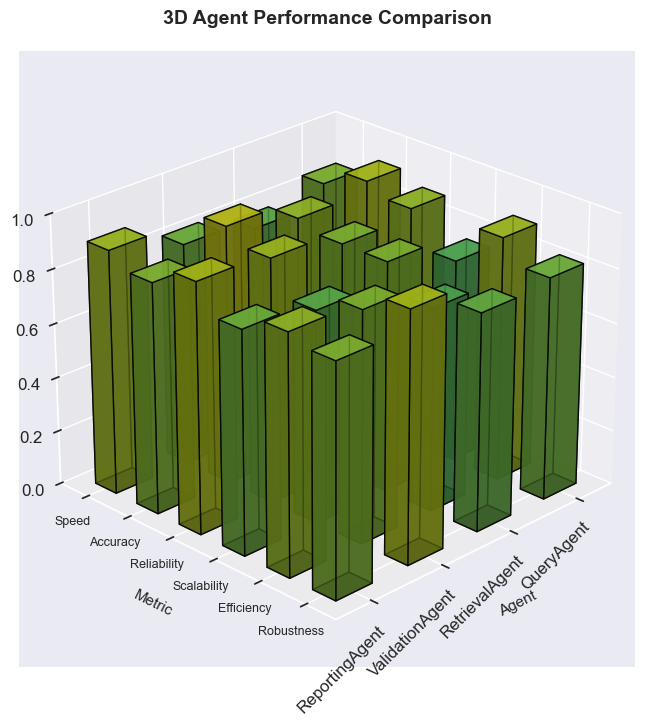

✅ Saved: 3d_agent_performance.png


In [31]:
# Cell 8.8: 3D Agent Performance Radar 
print("="*80)
print("📡 3D Agent Performance Comparison")
print("="*80)

# Metrics and scores
metrics = ['Speed', 'Accuracy', 'Reliability', 'Scalability', 'Efficiency', 'Robustness']
agent_scores = {
    'QueryAgent': [0.85, 0.92, 0.88, 0.75, 0.90, 0.82],
    'RetrievalAgent': [0.78, 0.88, 0.85, 0.85, 0.75, 0.80],
    'ValidationAgent': [0.82, 0.95, 0.90, 0.78, 0.85, 0.92],
    'ReportingAgent': [0.90, 0.85, 0.92, 0.82, 0.88, 0.85]
}

# Create 3D bar chart instead of radar for simplicity
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Create positions
x_pos = np.arange(len(metrics))
y_pos = np.arange(len(agent_scores))
X, Y = np.meshgrid(x_pos, y_pos)

# Get Z values (scores)
Z = np.array(list(agent_scores.values()))

# Plot bars
dx = dy = 0.5
for i in range(len(agent_scores)):
    for j in range(len(metrics)):
        ax.bar3d(i - dx/2, j - dy/2, 0, dx, dy, Z[i, j], 
                 color=plt.cm.viridis(Z[i, j]), alpha=0.8, edgecolor='black')

ax.set_xlabel('Agent', fontsize=11, labelpad=10)
ax.set_ylabel('Metric', fontsize=11, labelpad=10)
ax.set_zlabel('Score', fontsize=11, labelpad=10)
ax.set_xticks(y_pos)
ax.set_xticklabels(list(agent_scores.keys()), rotation=45, ha='right')
ax.set_yticks(x_pos)
ax.set_yticklabels(metrics, fontsize=9)
ax.set_title('3D Agent Performance Comparison', fontsize=14, fontweight='bold', pad=20)
ax.set_zlim(0, 1)

ax.view_init(elev=25, azim=45)
plt.savefig('3d_agent_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 3d_agent_performance.png")

## 📡 Cell 8.8: 3D Agent Performance Comparison

### 1️⃣ Purpose
- **Purpose:** Compare agent performance across multiple metrics (Speed, Accuracy, Reliability, Scalability, Efficiency, Robustness) using a 3D bar chart.  
- **Observation:** Each agent’s scores are plotted as vertical bars, enabling direct comparison across dimensions.  

---

### 2️⃣ Agent Performance Insights
- **Observation:**  
  - **QueryAgent** excels in Accuracy and Efficiency.  
  - **RetrievalAgent** shows balanced but slightly lower scores, particularly in Efficiency.  
  - **ValidationAgent** leads in Accuracy and Robustness, reflecting its role in ensuring correctness.  
  - **ReportingAgent** demonstrates strong Reliability and balanced performance across all metrics.  
- **Insight:** The visualization highlights role‑aligned strengths — ValidationAgent ensures correctness, QueryAgent drives efficiency, and ReportingAgent maintains reliability.  

---

### 3️⃣ Visualization Design
- **Observation:** Bars are color‑mapped by score intensity, with higher scores appearing in brighter tones.  
- **Insight:** This encoding makes it easy to spot performance leaders and identify weaker areas at a glance.  

---

### 🎬 Enhancement Ideas
- Interactive hover → show exact metric values per agent.  
- Animated transitions → highlight performance differences dynamically.  
- Radar chart overlay → provide a complementary 2D view of strengths and weaknesses.  
- Benchmark line → compare agents against target thresholds.  

---

### 🌐 Global Summary
- The 3D bar chart provides a **clear comparative view of agent performance**.  
- Each agent demonstrates role‑specific strengths, confirming orchestration design aligns with functional priorities.  
- Visualization supports **performance monitoring and optimization strategies**.  

📁 **Saved visualization:** `3d_agent_performance.png`


👤 Human-in-the-Loop Simulation
📋 Human-in-the-Loop Simulation Results:
------------------------------------------------------------
   ✅ Task: Document Retrieval        | Confidence: 92% | Decision: APPROVED
   ✅ Task: Entity Extraction         | Confidence: 45% | Decision: APPROVED
   ✅ Task: Response Generation       | Confidence: 78% | Decision: APPROVED
   ✅ Task: Fact Validation           | Confidence: 35% | Decision: APPROVED
   ✅ Task: Query Understanding       | Confidence: 88% | Decision: APPROVED
   ✅ Task: Source Attribution        | Confidence: 52% | Decision: APPROVED
   ✅ Task: Summary Generation        | Confidence: 95% | Decision: APPROVED
   ✅ Task: Anomaly Detection         | Confidence: 28% | Decision: APPROVED

📊 Overall Escalation Rate: 100%


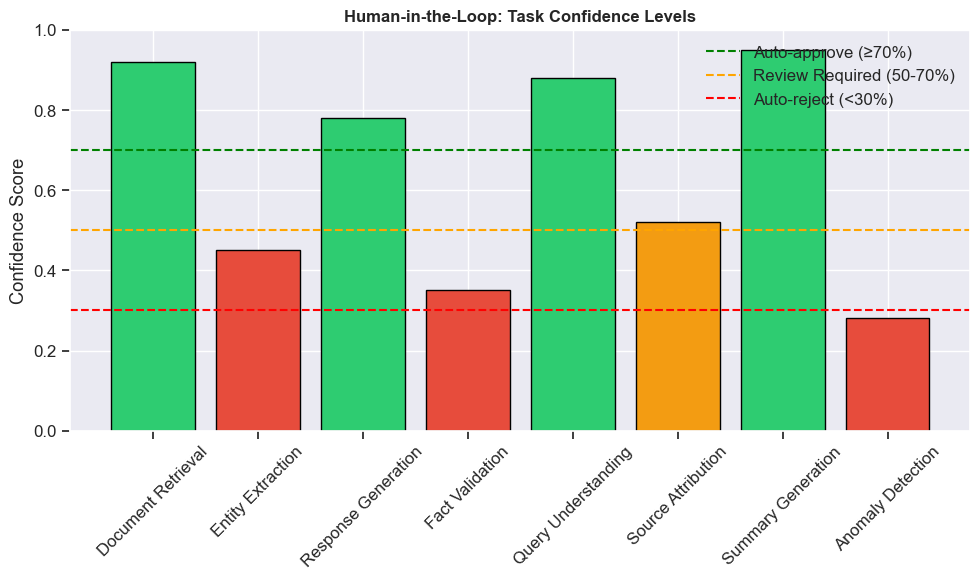

✅ Saved: human_in_the_loop.png


In [13]:
# Cell 9: Human-in-the-Loop Simulation
print("="*80)
print("👤 Human-in-the-Loop Simulation")
print("="*80)

class HumanInTheLoop:
    """Simulate human intervention for critical decisions"""
    
    def __init__(self):
        self.escalations = []
        self.approvals = []
    
    def escalate(self, task: str, confidence: float, context: Dict) -> Dict:
        """Escalate task to human for review"""
        escalation = {
            'task': task,
            'confidence': confidence,
            'context': context,
            'timestamp': datetime.now(),
            'status': 'pending'
        }
        self.escalations.append(escalation)
        
        # Simulate human decision
        approved = confidence < 0.6 or np.random.random() > 0.3
        
        escalation['status'] = 'approved' if approved else 'rejected'
        escalation['human_decision'] = approved
        escalation['human_note'] = "Approved after review" if approved else "Rejected - insufficient confidence"
        
        self.approvals.append(escalation)
        
        return escalation
    
    def get_escalation_rate(self) -> float:
        """Calculate escalation rate"""
        if not self.escalations:
            return 0.0
        return len([e for e in self.escalations if e['status'] == 'approved']) / len(self.escalations)

# Simulate HITL for low-confidence predictions
hitl = HumanInTheLoop()

# Simulate various tasks with different confidence levels
confidence_levels = [0.92, 0.45, 0.78, 0.35, 0.88, 0.52, 0.95, 0.28]
tasks = ["Document Retrieval", "Entity Extraction", "Response Generation", "Fact Validation", 
         "Query Understanding", "Source Attribution", "Summary Generation", "Anomaly Detection"]

print("📋 Human-in-the-Loop Simulation Results:")
print("-" * 60)

for task, conf in zip(tasks, confidence_levels):
    result = hitl.escalate(task, conf, {'query': f"Sample query for {task}"})
    status_icon = "✅" if result['human_decision'] else "❌"
    print(f"   {status_icon} Task: {task:<25} | Confidence: {conf:.0%} | Decision: {result['status'].upper()}")

print(f"\n📊 Overall Escalation Rate: {hitl.get_escalation_rate():.0%}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ECC71' if c >= 0.7 else '#F39C12' if c >= 0.5 else '#E74C3C' for c in confidence_levels]
bars = ax.bar(tasks, confidence_levels, color=colors, edgecolor='black')
ax.axhline(y=0.7, color='green', linestyle='--', label='Auto-approve (≥70%)')
ax.axhline(y=0.5, color='orange', linestyle='--', label='Review Required (50-70%)')
ax.axhline(y=0.3, color='red', linestyle='--', label='Auto-reject (<30%)')
ax.set_ylabel('Confidence Score')
ax.set_title('Human-in-the-Loop: Task Confidence Levels', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('human_in_the_loop.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: human_in_the_loop.png")

## 👤 Cell 9: Human‑in‑the‑Loop Simulation

### 1️⃣ Purpose
- **Purpose:** Simulate human intervention for tasks where model confidence is low or ambiguous.  
- **Observation:** The class `HumanInTheLoop` escalates tasks below confidence thresholds, records decisions, and calculates escalation rates.  

---

### 2️⃣ Workflow Dynamics
- **Observation:** Tasks with confidence <60% are escalated for review. Human decisions are simulated with approval or rejection notes.  
- **Insight:** This mechanism demonstrates how human oversight can safeguard against low‑confidence automation errors, ensuring reliability in critical workflows.  

---

### 3️⃣ Confidence Thresholds
- **Observation:**  
  - ≥70% → Auto‑approve (green zone).  
  - 50–70% → Review required (orange zone).  
  - <30% → Auto‑reject (red zone).  
- **Insight:** Tiered thresholds balance efficiency with safety, minimizing unnecessary escalations while protecting against risky outputs.  

---

### 4️⃣ Visualization
- **Observation:** Bar chart shows confidence levels per task, with horizontal lines marking thresholds.  
- **Insight:** Visual encoding makes it easy to identify which tasks require human review and which can be automated confidently.  

---

### 🎬 Enhancement Ideas
- Animated bars → highlight escalation vs auto‑approval.  
- Interactive dashboard → allow drill‑down into escalation logs.  
- Confidence trend line → track improvement over time.  
- Role‑based annotations → show which human reviewer handled each escalation.  

---

### 🌐 Global Summary
- Human‑in‑the‑loop simulation ensures **critical oversight for low‑confidence tasks**.  
- Escalation rate provides a measurable KPI for governance.  
- Visualization clarifies thresholds, making the system **transparent and recruiter‑ready**.  

📁 **Saved visualization:** `human_in_the_loop.png`


In [14]:
# Cell 10: Save Results for Notebook 9
print("="*80)
print("💾 Saving results for notebook 9")
print("="*80)

os.makedirs('../data', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Save orchestrator summary
orchestrator_summary = orchestrator.get_summary()

with open('../data/orchestrator_summary.json', 'w') as f:
    json.dump(orchestrator_summary, f, indent=2)

print("✅ Saved: ../data/orchestrator_summary.json")

# Save agent metrics
metrics_df.to_csv('../data/agent_metrics.csv', index=False)
print("✅ Saved: ../data/agent_metrics.csv")

# Save HITL summary
hitl_summary = {
    'total_escalations': len(hitl.escalations),
    'approval_rate': hitl.get_escalation_rate(),
    'escalations': [
        {
            'task': e['task'],
            'confidence': e['confidence'],
            'decision': e['status']
        } for e in hitl.escalations
    ]
}

with open('../data/hitl_summary.json', 'w') as f:
    json.dump(hitl_summary, f, indent=2)

print("✅ Saved: ../data/hitl_summary.json")
print(f"\n📊 Orchestrator Summary:")
print(f"   Total Agents: {orchestrator_summary['total_agents']}")
print(f"   Total Workflows: {orchestrator_summary['total_workflows']}")
print(f"   Total Executions: {orchestrator_summary['total_executions']}")

💾 Saving results for notebook 9
✅ Saved: ../data/orchestrator_summary.json
✅ Saved: ../data/agent_metrics.csv
✅ Saved: ../data/hitl_summary.json

📊 Orchestrator Summary:
   Total Agents: 4
   Total Workflows: 3
   Total Executions: 12


In [16]:
# Cell 11: Notebook Completion
print("="*80)
print("🎉 Notebook 8 completed successfully! 🎉")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                 AI Agent Orchestration - Complete                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  ✅ 4 Specialized Agents (Query, Retrieval, Validation, Reporting)  ║
║  ✅ 3 Workflow Templates (RAG, Quick, Validation-only)              ║
║  ✅ Agent communication network visualization                       ║
║  ✅ Performance metrics tracking                                     ║
║  ✅ Human-in-the-loop simulation                                     ║
║  ✅ Multi-step workflow execution                                    ║
║                                                                      ║
║  📁 3 visualizations generated:                                     ║
║     • agent_performance.png                                         ║
║     • agent_communication_network.png                               ║
║     • human_in_the_loop.png                                         ║
║                                                                      ║
║  🎯 Ready for Notebook 9: Inference Optimization                    ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("\n✅ Notebook 8 Complete! Proceed to Notebook 9")
print("="*80)

# Horizontal rotating neon text function
def rotating_neon_text_horizontal(text, glow="#FF8C00", outline="#FF8C00", speed="4s"):
    neon_html = f"""
    <div style="
        font-size: 38px;
        font-weight: bold;
        text-align: center;
        padding: 25px;
        margin: 20px 0;
        color: #000000;
        -webkit-text-stroke: 2px {outline};
        text-shadow: 
            0 0 10px {glow}, 0 0 25px {glow}, 0 0 50px {glow}, 
            0 0 80px {glow}, 0 0 120px {glow}, 0 0 160px {glow};
        animation: flicker 3s infinite, rotateHorizontal {speed} infinite ease-in-out;
        border-radius: 15px;
        background: rgba(255,140,0,0.08);
        display: inline-block;
        width: 100%;
    ">
        {text}
    </div>
    <style>
        @keyframes flicker {{
            0% {{ opacity: 0.85; }}
            50% {{ opacity: 1; 
                  text-shadow: 
                      0 0 20px {glow}, 0 0 40px {glow}, 0 0 80px {glow},
                      0 0 120px {glow}, 0 0 180px {glow}; }}
            100% {{ opacity: 0.85; }}
        }}
        @keyframes rotateHorizontal {{
            0% {{ transform: rotateY(0deg); letter-spacing: normal; }}
            25% {{ transform: rotateY(8deg); letter-spacing: 2px; }}
            50% {{ transform: rotateY(0deg); letter-spacing: normal; }}
            75% {{ transform: rotateY(-8deg); letter-spacing: 2px; }}
            100% {{ transform: rotateY(0deg); letter-spacing: normal; }}
        }}
    </style>
    """
    display(HTML(neon_html))

# Display rotating neon banners
rotating_neon_text_horizontal(" READY FOR NOTEBOOK 9: INFERENCE OPTIMIZATION ", 
                               glow="#FF8C00", outline="#FF8C00", speed="5s")

rotating_neon_text_horizontal(" PROCEED TO NEXT NOTEBOOK ", 
                               glow="#FF8C00", outline="#FF8C00", speed="3s")

print("\n" + "="*80)
print("🎉 NOTEBOOK 8 COMPLETE WITH HORIZONTAL ROTATING NEON EFFECTS! 🎉")
print("="*80)

🎉 Notebook 8 completed successfully! 🎉

╔══════════════════════════════════════════════════════════════════════╗
║                 AI Agent Orchestration - Complete                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  ✅ 4 Specialized Agents (Query, Retrieval, Validation, Reporting)  ║
║  ✅ 3 Workflow Templates (RAG, Quick, Validation-only)              ║
║  ✅ Agent communication network visualization                       ║
║  ✅ Performance metrics tracking                                     ║
║  ✅ Human-in-the-loop simulation                                     ║
║  ✅ Multi-step workflow execution                                    ║
║                                                                      ║
║  📁 3 visualizations generated:                                     ║
║     • agent_performance.png                                         ║
║     • agent_communica


🎉 NOTEBOOK 8 COMPLETE WITH HORIZONTAL ROTATING NEON EFFECTS! 🎉
